In [1]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


📊 Всего строк: 720
📊 Колонки: ['review_text', 'true_label', 'prompt_style', 'temperature', 'category', 'product', 'rating', 'sample_id']
📝 Используем колонку: review_text
🔄 Выполняется предобработка текста...
✅ Предобработка завершена

📝 Примеры после предобработки:
  Оригинал: I've been using this fitness tracker for a few weeks now, and it's been decent. ...
  Обработан: I have been using this fitness tracker for a few weeks now and it is been decent...

  Оригинал: I recently purchased this leather watch and have been wearing it for a few weeks...
  Обработан: I recently purchased this leather watch and have been wearing it for a few weeks...

  Оригинал: I've been using this knife set for a few weeks now and overall, I'm pretty satis...
  Обработан: I have been using this knife set for a few weeks now and overall I am pretty sat...


🤖 Загрузка RoBERTa model for feature extraction...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🔄 Извлечение признаков из текста...
✅ Признаки извлечены: (720, 768)

🔄 One-hot encoding категорий...
  Категории: ['Sports_and_Outdoors_5' 'Clothing_Shoes_and_Jewelry_5'
 'Home_and_Kitchen_5' 'Office_Products_5' 'Beauty_5' 'Toys_and_Games_5'
 'Books_5' 'Pet_Supplies_5' 'Electronics_5' 'Movies_and_TV_5']
  One-hot форма: (720, 10)
📊 Рейтинги: доступны, форма (720, 1)

🔗 Объединённые признаки: (720, 779)

🔮 Выполнение предсказаний...

РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ
Всего отзывов: 720
Предсказано фейков (CG): 273 (37.9%)
Предсказано настоящих (OR): 447 (62.1%)

📊 Точность на тестовых данных: 0.6597 (65.97%)

Classification Report:
              precision    recall  f1-score   support

        fake       0.93      0.53      0.67       480
        real       0.49      0.92      0.64       240

    accuracy                           0.66       720
   macro avg       0.71      0.72      0.66       720
weighted avg       0.79      0.66      0.66       720



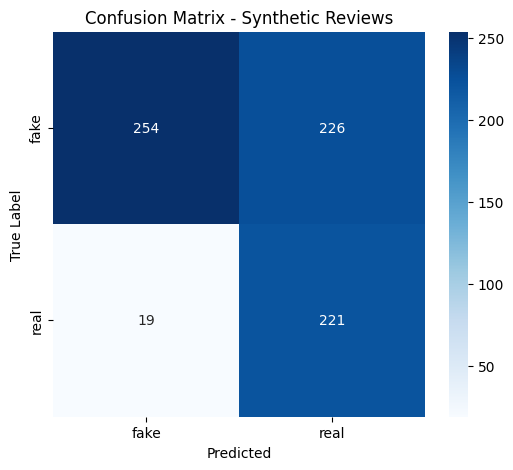


АНАЛИЗ ПО СТИЛЯМ ПРОМПТОВ

% предсказанных фейков по стилям:
               fake_percent
prompt_style               
humanized         30.000000
simple            39.166667
with_examples     44.583333

% предсказанных фейков по температурам:
             fake_percent
temperature              
0.0             45.000000
0.2             41.111111
0.5             35.555556
1.0             30.000000


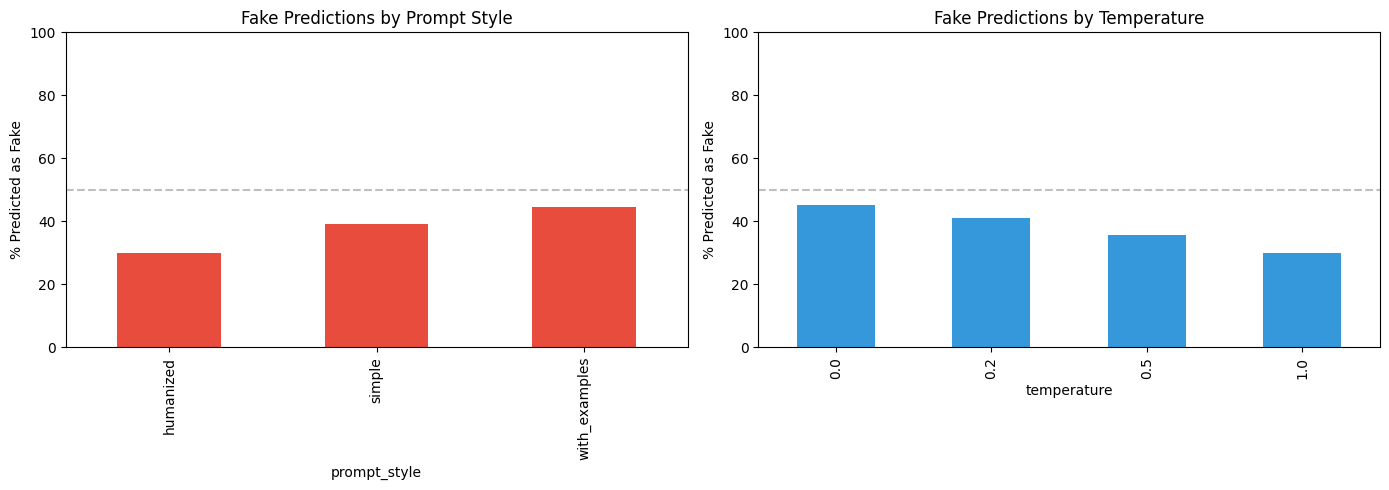

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Результаты сохранены в synthetic_predictions_roberta_xgboost.csv
📊 Файл содержит 720 строк и 14 колонок

📋 Примеры предсказаний:
  true_label prompt_style  temperature pred_class  prob_fake
0    organic       simple          0.0  real (OR)   0.041430
1    organic       simple          0.0  real (OR)   0.000514
2    organic       simple          0.0  real (OR)   0.000025
3    organic       simple          0.0  real (OR)   0.000937
4    organic       simple          0.0  fake (CG)   0.606902
5    organic       simple          0.0  real (OR)   0.000020
6    organic       simple          0.0  real (OR)   0.001481
7    organic       simple          0.0  fake (CG)   0.821549
8    organic       simple          0.0  real (OR)   0.002156
9    organic       simple          0.0  real (OR)   0.100130


In [2]:
# ============================================
# 1. Импорт библиотек
# ============================================
import pandas as pd
import numpy as np
import re
import contractions
from transformers import pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import joblib
from google.colab import files

# ============================================
# 2. Загрузка синтетических отзывов (CSV)
# ============================================
# Загрузка файла


# Загрузка с пропуском первой строки
df = pd.read_csv('/kaggle/input/datasets/tarasovartem/goodcsv/Synthetic Reviews Complete May 21 2026.csv')

print(f"📊 Всего строк: {len(df)}")
print(f"📊 Колонки: {df.columns.tolist()}")

# Определяем колонку с текстом
text_col = None
for col in ['review_text', 'text', 'text_', 'review']:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError(f"Не найдена колонка с текстом. Доступны: {df.columns.tolist()}")

print(f"📝 Используем колонку: {text_col}")

# ============================================
# 3. Текстовая предобработка (как в вашем ноутбуке)
# ============================================
def preprocess_text(text):
    """
    Текстовая предобработка, идентичная той, что в ноутбуке
    """
    # Contraction Handling (don't -> do not)
    text = contractions.fix(str(text))
    # Removing Punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Adding Space (where a space should be) - для слов в CamelCase
    text = re.sub(r'(?<!^)(?=[A-Z])', ' ', text)
    # Removing Extra Spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🔄 Выполняется предобработка текста...")
df['clean_text'] = df[text_col].apply(preprocess_text)
print(f"✅ Предобработка завершена")

# Показываем примеры
print("\n📝 Примеры после предобработки:")
for i in range(min(3, len(df))):
    print(f"  Оригинал: {str(df[text_col].iloc[i])[:80]}...")
    print(f"  Обработан: {df['clean_text'].iloc[i][:80]}...")
    print()

# ============================================
# 4. Извлечение признаков через RoBERTa
# ============================================
print("\n🤖 Загрузка RoBERTa model for feature extraction...")
feature_extractor = pipeline(
    "feature-extraction",
    framework="pt",
    model="FacebookAI/roberta-base",
    device=0  # Используем GPU если доступен
)

print("🔄 Извлечение признаков из текста...")
features = []

for feature in feature_extractor(
    df['clean_text'].tolist(),
    return_tensors="pt",
    truncation=True,
    batch_size=32
):
    # Усреднение по токенам для получения одного вектора на отзыв
    feature_mean = feature[0].numpy().mean(axis=0)
    features.append(feature_mean)

features_np = np.array(features)
print(f"✅ Признаки извлечены: {features_np.shape}")

# ============================================
# 5. Обработка категориальных признаков
# ============================================
# Проверяем наличие колонки 'category'
if 'category' in df.columns:
    print("\n🔄 One-hot encoding категорий...")
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_category = encoder.fit_transform(df[['category']])
    print(f"  Категории: {df['category'].unique()}")
    print(f"  One-hot форма: {encoded_category.shape}")
else:
    # Если нет категории, создаем заглушку
    print("\n⚠️ Колонка 'category' не найдена, пропускаем one-hot encoding")
    encoded_category = np.zeros((len(df), 1))

# ============================================
# 6. Обработка рейтинга
# ============================================
if 'rating' in df.columns:
    rating = df['rating'].fillna(3).values.reshape(-1, 1)
    print(f"📊 Рейтинги: доступны, форма {rating.shape}")
else:
    print("⚠️ Колонка 'rating' не найдена, использую 3 (средний рейтинг)")
    rating = np.ones((len(df), 1)) * 3

# ============================================
# 7. Объединение всех признаков
# ============================================
combined = np.concatenate((encoded_category, rating, features_np), axis=1)
print(f"\n🔗 Объединённые признаки: {combined.shape}")

# ============================================
# 8. Загрузка обученной модели и предсказание
# ============================================

model = joblib.load('/kaggle/input/datasets/tarasovartem/coursewor/XGBoost RoBERTa Model.pkl')

# Предсказания
print("\n🔮 Выполнение предсказаний...")
predictions = model.predict(combined)
probabilities = model.predict_proba(combined)

# Добавляем предсказания в DataFrame
df['pred_label'] = predictions
df['pred_class'] = df['pred_label'].map({0: 'fake (CG)', 1: 'real (OR)'})
df['prob_fake'] = probabilities[:, 0]
df['prob_real'] = probabilities[:, 1]

# ============================================
# 9. Результаты
# ============================================
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ")
print("="*60)

print(f"Всего отзывов: {len(df)}")
print(f"Предсказано фейков (CG): {(predictions == 0).sum()} ({(predictions == 0).mean()*100:.1f}%)")
print(f"Предсказано настоящих (OR): {(predictions == 1).sum()} ({(predictions == 1).mean()*100:.1f}%)")

# Если есть true_label, оцениваем качество
if 'true_label' in df.columns:
    label_map = {'organic': 1, 'bot_generated': 0, 'incentivized': 0,
                 'real': 1, 'fake': 0, 'OR': 1, 'CG': 0}
    df['true_binary'] = df['true_label'].map(label_map)

    valid = df.dropna(subset=['true_binary'])
    if len(valid) > 0:
        from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
        acc = accuracy_score(valid['true_binary'], valid['pred_label'])
        print(f"\n📊 Точность на тестовых данных: {acc:.4f} ({acc*100:.2f}%)")
        print("\nClassification Report:")
        print(classification_report(valid['true_binary'], valid['pred_label'],
                                   target_names=['fake', 'real']))

        # Confusion Matrix
        cm = confusion_matrix(valid['true_binary'], valid['pred_label'])
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
        plt.title('Confusion Matrix - Synthetic Reviews')
        plt.ylabel('True Label')
        plt.xlabel('Predicted')
        plt.show()

# ============================================
# 10. Анализ по стилям промптов и температурам
# ============================================
if 'prompt_style' in df.columns and 'temperature' in df.columns:
    print("\n" + "="*60)
    print("АНАЛИЗ ПО СТИЛЯМ ПРОМПТОВ")
    print("="*60)

    style_stats = df.groupby('prompt_style').agg({
        'pred_label': lambda x: (x == 0).mean() * 100
    }).rename(columns={'pred_label': 'fake_percent'})

    print("\n% предсказанных фейков по стилям:")
    print(style_stats)

    temp_stats = df.groupby('temperature').agg({
        'pred_label': lambda x: (x == 0).mean() * 100
    }).rename(columns={'pred_label': 'fake_percent'})

    print("\n% предсказанных фейков по температурам:")
    print(temp_stats)

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    style_stats.plot(kind='bar', ax=axes[0], color='#e74c3c', legend=False)
    axes[0].set_title('Fake Predictions by Prompt Style')
    axes[0].set_ylabel('% Predicted as Fake')
    axes[0].set_ylim(0, 100)
    axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

    temp_stats.plot(kind='bar', ax=axes[1], color='#3498db', legend=False)
    axes[1].set_title('Fake Predictions by Temperature')
    axes[1].set_ylabel('% Predicted as Fake')
    axes[1].set_ylim(0, 100)
    axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ============================================
# 11. Сохранение результатов
# ============================================
output_filename = 'synthetic_predictions_roberta_xgboost.csv'
df.to_csv(output_filename, index=False, encoding='utf-8')
files.download(output_filename)

print(f"\n✅ Результаты сохранены в {output_filename}")
print(f"📊 Файл содержит {len(df)} строк и {len(df.columns)} колонок")

# Показываем примеры
print("\n📋 Примеры предсказаний:")
print(df[['true_label', 'prompt_style', 'temperature', 'pred_class', 'prob_fake']].head(10))